In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the stock data from the csv file
df = pd.read_csv('RELIANCE.csv')
print(df.shape)
df.head()

(5306, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [3]:
# check column names, data types and missing values
print(df.columns)
print(df.info())
print(df.isnull().sum())

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades       

In [4]:
# convert the date column to a proper date format 
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
print(df.head())

        Date    Symbol Series  Prev Close    Open    High     Low    Last  \
0 2000-01-03  RELIANCE     EQ      233.05  237.50  251.70  237.50  251.70   
1 2000-01-04  RELIANCE     EQ      251.70  258.40  271.85  251.30  271.85   
2 2000-01-05  RELIANCE     EQ      271.85  256.65  287.90  256.65  286.75   
3 2000-01-06  RELIANCE     EQ      282.50  289.00  300.70  289.00  293.50   
4 2000-01-07  RELIANCE     EQ      294.35  295.00  317.90  293.00  314.50   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  251.70  249.37   4456424  1.111319e+14     NaN                 NaN   
1  271.85  263.52   9487878  2.500222e+14     NaN                 NaN   
2  282.50  274.79  26833684  7.373697e+14     NaN                 NaN   
3  294.35  295.45  15682286  4.633254e+14     NaN                 NaN   
4  314.55  308.91  19870977  6.138388e+14     NaN                 NaN   

   %Deliverble  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          Na

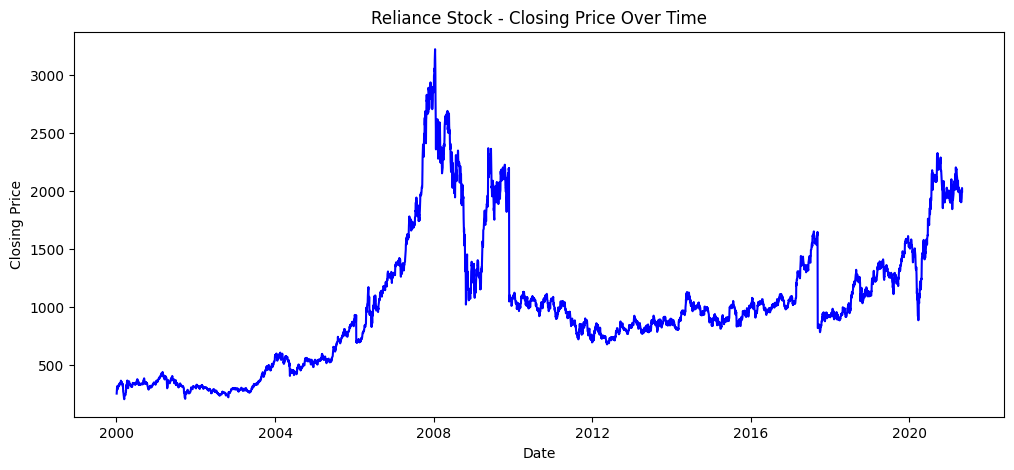

In [ ]:
# plot the closing price over time to see the overall trend
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Reliance Stock - Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

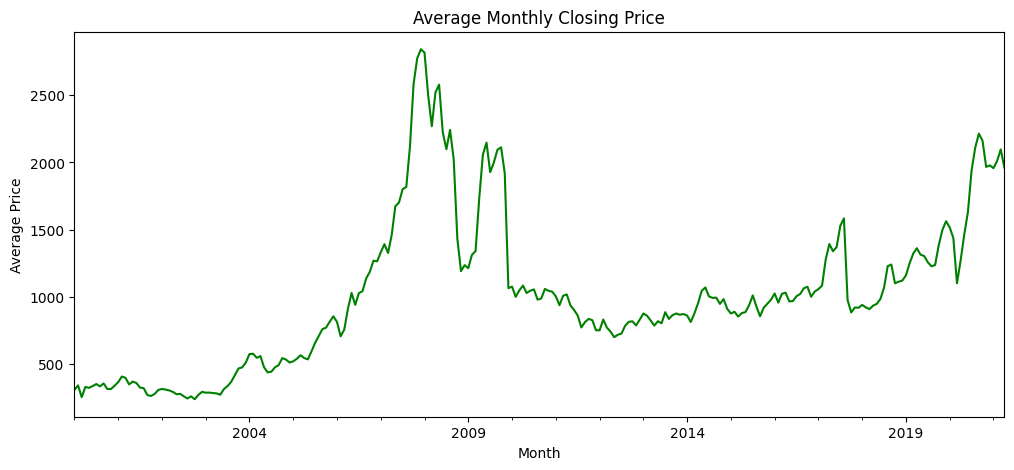

In [6]:
# group the data by month and calculate the average closing price each month
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(12, 5))
monthly.plot(color='green')
plt.title('Average Monthly Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.show()

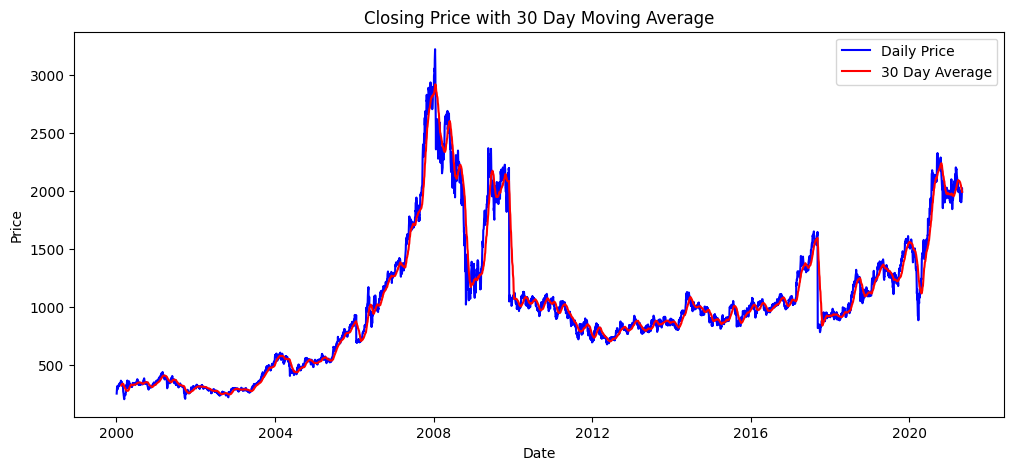

In [7]:
#  moving average 
df['30day_avg'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='blue', label='Daily Price')
plt.plot(df['Date'], df['30day_avg'], color='red', label='30 Day Average')
plt.title('Closing Price with 30 Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [8]:
# show basic statistics about the closing price
print(df['Close'].describe())

count    5306.000000
mean     1011.316839
std       571.046753
min       203.200000
25%       572.512500
50%       938.275000
75%      1248.275000
max      3220.850000
Name: Close, dtype: float64
